In [2]:
# Run this setup only in Google Colab
import os
import subprocess
import sys

try:
    from google.colab import drive
    drive.mount("/content/drive")
    os.chdir("/content/drive/MyDrive/Colab Notebooks/ml2_trabalhos_2026")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"])
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-e", ".", "--no-deps"])
except ModuleNotFoundError:
    print("Not running in Colab; skipping Drive mount and install steps.")

Not running in Colab; skipping Drive mount and install steps.


# Trabalho 1 - Classificação de imagens com o Oxford-IIIT Pet

Neste trabalho, você irá treinar e comparar diferentes modelos para classificação de raças no dataset **Oxford-IIIT Pet**.

**Objetivos.**
- construir um pipeline básico de classificação de imagens;
- comparar arquiteturas simples e profundas;
- investigar o efeito de escolhas de treinamento;
- analisar erros e limitações do modelo.

**Entregáveis.**
1. Este notebook preenchido e executado.
2. Os pesos do melhor modelo;
2. Respostas curtas e objetivas nas células de texto.
3. Tabelas e gráficos pedidos ao longo do trabalho.

**Regras gerais.**
- Use **PyTorch**.
- Registre as escolhas principais de hiperparâmetros.
- Quando o enunciado pedir comparação, use evidências dos seus resultados.
- Não apague as células do enunciado.
- Use o conjunto de **teste** apenas na etapa final.



## Parte 0 — Setup e reprodutibilidade

Como treinamos algoritmos que possuem escolhas randômicas, e em máquinas com configurações possivelmente distintas. É importante tentar controlar essas variáveis para garantirmos o máximo de reprodutibilidade dos nossos experimentos.

**Tarefa 0.1**  
Fixe as seeds aleatórias e configure o dispositivo (`cpu` ou `cuda`).

**Tarefa 0.2**  
Imprima as versões de `torch` e `torchvision`, e indique se o notebook está usando CPU ou GPU.

**Tarefa 0.3**  
Crie uma variável `student_run_tag` com uma string curta de sua escolha (por exemplo, suas iniciais e a data).  
Use essa tag ao salvar modelos, figuras e demais artefatos produzidos no notebook.



## Configuração do Ambiente e Reprodutibilidade

Para que seja garantida a consistência dos experimentos, é preciso que seja definida (seeds) globais para todas as bibliotecas que serão  utilizadas nos processos aleatórios. Além disso, é ideal que seja configurado o suporte à aceleração por hardware (GPU/CUDA), o que é fundamental para o treinamento eficiente de redes neurais profundas.

Para o desenvolvimento deste trabalho, será utilizado o ecossistema `PyTorch`. Além do núcleo do framework (torch), empregando o módulo `torch.nn` para a construção das camadas da rede e o `torch.optim` para a implementação dos algoritmos de otimização. A visualização de dados e resultados será realizada através da biblioteca `matplotlib`.

In [4]:
# TODO: importe as bibliotecas principais
import random
import numpy as np
from pathlib import Path
import torch.optim as optim
import torch.nn as nn
import matplotlib.pyplot as plt


import torch
import torchvision

# Sugestão: complete com torch.nn, torch.optim, matplotlib etc.

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Semente: {seed}")
print(f"Dispositivo: {device}")
print("Versão do Torch:", torch.__version__)
print("Versão do Torchvision:", torchvision.__version__)

student_run_tag = "version_1_Herivelton"
output_dir = Path("assignment1_outputs")
output_dir.mkdir(exist_ok=True)
(output_dir / student_run_tag).mkdir(exist_ok=True)
print("Diretório de saída:", output_dir / student_run_tag)

Semente: 42
Dispositivo: cuda
Versão do Torch: 2.7.1+cu118
Versão do Torchvision: 0.22.1+cu118
Diretório de saída: assignment1_outputs/version_1_Herivelton


## 1. Carregar dados e fazer split

Use o dataset **Oxford-IIIT Pet** do `torchvision`.

**Tarefas**
1. Baixe/carregue o dataset.
2. Separe os dados em **treino**, **validação** e **teste**.
3. Explique brevemente qual split você usou.
4. Mostre o número de exemplos em cada parte.

**Observação.**
- Você pode usar o split oficial de treino/teste e separar parte do treino para validação.
- Para a maior parte do trabalho, use inicialmente transformações simples.


In [5]:
# TODO:
# - importar OxfordIIITPet
# - definir transformações iniciais
# - carregar conjuntos
# - criar split treino/validação
# - criar DataLoaders

# Estrutura sugerida:
# from torchvision.datasets import OxfordIIITPet
# from torchvision import transforms
# from torch.utils.data import DataLoader, random_split

image_size_padrao = 224
batch_size_padrao = 64

# Escreva seu código aqui

### 1.1 Carregamento e Preparação dos Dados

Nesta etapa, será realizado o download e a estruturação do dataset OxfordIIITPet. Utilizando a biblioteca `torchvision.transforms` para redimensionar as imagens para um formato padrão e convertê-las em tensores para ser possível o processamento computacional.

Para garantir uma avaliação robusta do modelo os dados serão dividimos em três conjuntos distintos:

### 1.2 - Separe os dados em **treino**, **validação** e **teste**.

A célula de código a seguir também apresenta a separa o conjunto em validação, treino e teste.
- Observação: o dataset `Oxford-IIIT Pet` foi criado por pesquisadores que decidiram dividir as fotos exatamente em duas partes (50% para treino/validação e 50% para teste).

### Resposta 1.3 Explique brevemente qual split você usou.

Explique brevemente como você construiu o split de treino, validação e teste.

- Treino: Utilizado para o ajuste dos pesos da rede neural, (efetivamente 80% do conjunto de dados de treino)

- Validação: Um subconjunto (20%) dos dados de treino, utilizado para monitorar o desempenho durante o processo e evitar o overfitting.

- Teste: Conjunto independente, utilizado apenas na fase final para medir a capacidade de generalização do modelo em dados nunca vistos.

O gerenciamento do fluxo de dados para a memória é feito através de DataLoaders, que organizam as imagens em lotes (batches), otimizando o uso do hardware.

### 1.4 Mostre o número de exemplos em cada parte.

Como reposta da célula de código também esta exposto a quantidade de dados de cada conjunto.

In [6]:
from torchvision.datasets import OxfordIIITPet
from torchvision import transforms
from torch.utils.data import DataLoader, random_split

transform_s = transforms.Compose([
                                transforms.Resize((image_size_padrao, image_size_padrao)), 
                                transforms.ToTensor()])

dataset = OxfordIIITPet(root='data_heri',
                        split='trainval',
                        target_types='category',
                        download=True,
                        transform=transform_s)

dataset_test = OxfordIIITPet(root='data_heri',
                             split='test',
                             target_types='category',
                             download=True,
                             transform=transform_s)

tamanho_train = int(0.8 * len(dataset))
tamanho_val = len(dataset) - tamanho_train
data_train, data_validacao = random_split(dataset, [tamanho_train, tamanho_val]) 

treino_loader = DataLoader(data_train,
                          batch_size=batch_size_padrao,
                          shuffle=True)
validacao_loader = DataLoader(data_validacao,
                              batch_size=batch_size_padrao,
                              shuffle=False)
teste_loader = DataLoader(dataset_test,
                          batch_size=batch_size_padrao,
                          shuffle=False)

print(f'Conjunto de Treino: {len(data_train)} imagens')
print(f'Conjunto de Validação: {len(data_validacao)} imagens')
print(f'Conjunto Teste: {len(dataset_test)} imagens')

100%|██████████| 792M/792M [01:15<00:00, 10.5MB/s]  
100%|██████████| 19.2M/19.2M [00:31<00:00, 614kB/s] 


Conjunto de Treino: 2944 imagens
Conjunto de Validação: 736 imagens
Conjunto Teste: 3669 imagens


## 2. Visualizar dados e inspecionar balanceamento

Antes de treinar, inspecione o dataset.

**Tarefas**
1. Mostre algumas imagens com seus rótulos.
2. Conte quantos exemplos há por classe no conjunto de treino.
3. Faça um gráfico simples da distribuição por classe.
4. Comente se o conjunto parece balanceado ou não.
5. Aponte ao menos uma dificuldade visual do problema.

Existem 37 raças diferentes no dataset.
Nomes das raças: ['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle', 'Bengal', 'Birman', 'Bombay', 'Boxer', 'British Shorthair', 'Chihuahua', 'Egyptian Mau', 'English Cocker Spaniel', 'English Setter', 'German Shorthaired', 'Great Pyrenees', 'Havanese', 'Japanese Chin', 'Keeshond', 'Leonberger', 'Maine Coon', 'Miniature Pinscher', 'Newfoundland', 'Persian', 'Pomeranian', 'Pug', 'Ragdoll', 'Russian Blue', 'Saint Bernard', 'Samoyed', 'Scottish Terrier', 'Shiba Inu', 'Siamese', 'Sphynx', 'Staffordshire Bull Terrier', 'Wheaten Terrier', 'Yorkshire Terrier']


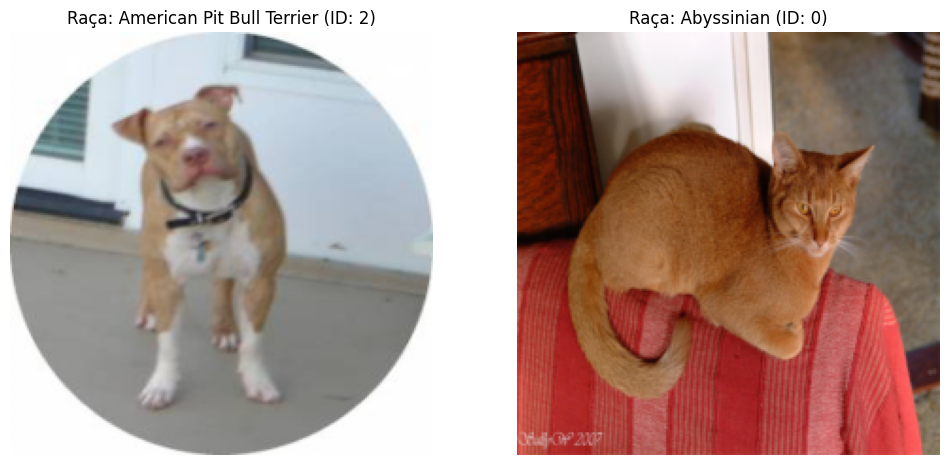

In [7]:

nomes_classes = dataset.classes
print(f"Existem {len(nomes_classes)} raças diferentes no dataset.")
print(f"Nomes das raças: {nomes_classes}") 

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1) # posição 1
imagem_125, label_125 = dataset[125]
plt.imshow(imagem_125.permute(1, 2, 0))
plt.title(f"Raça: {nomes_classes[label_125]} (ID: {label_125})")
plt.axis('off')


plt.subplot(1, 2, 2) # posição 2
imagem_12, label_12 = dataset[12]
plt.imshow(imagem_12.permute(1, 2, 0))
plt.title(f"Raça: {nomes_classes[label_12]} (ID: {label_12})")
plt.axis('off')

plt.show()

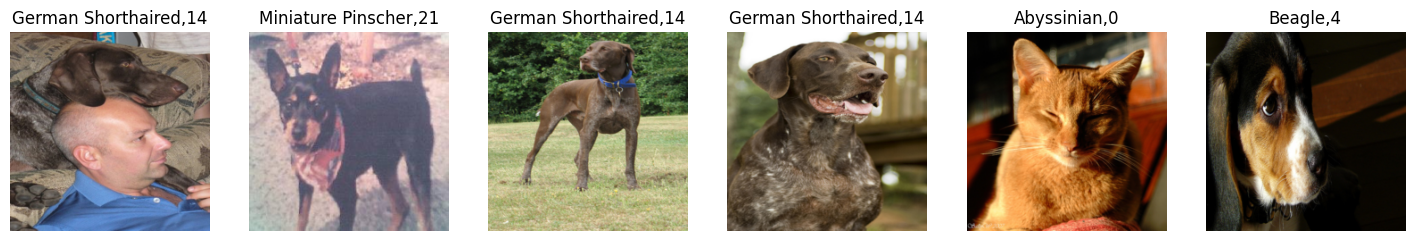

In [62]:
plt.figure(figsize=(18, 6))

for i in range(6):
    imagem_tensor, indice_raca = data_train[random.randint(0, len(data_train)-1)]
    imagem_para_mostrar = imagem_tensor.permute(1, 2, 0)
    plt.subplot(1, 6, i+1)
    plt.imshow(imagem_para_mostrar)
    plt.title(f'{nomes_classes[indice_raca]},{indice_raca}')
    plt.axis('off') 
plt.show()

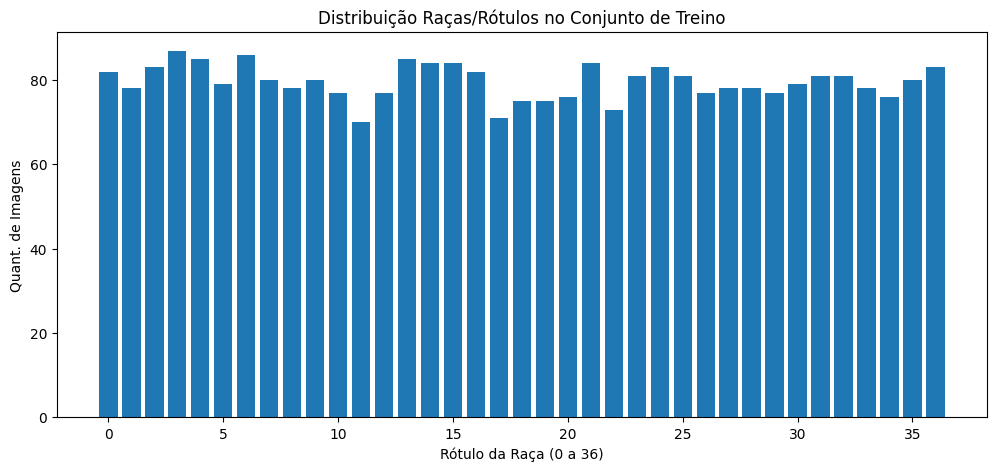

In [9]:
# TODO:
# - mostrar algumas imagens do treino
# - obter nomes/classes
# - contar frequência por classe
# - fazer um gráfico simples

from collections import Counter
etiquetas_treino = []
for imagem_qualquer, label in data_train:
    etiquetas_treino.append(label)

contagem = Counter(etiquetas_treino)

# Gerando gráfico de barras com a frequência de cada classe
plt.figure(figsize=(12, 5))
plt.bar(contagem.keys(), contagem.values())
plt.title("Distribuição Raças/Rótulos no Conjunto de Treino")
plt.xlabel("Rótulo da Raça (0 a 36)")
plt.ylabel("Quant. de Imagens")
plt.show()

### DataFrame/Tabela de Frequência por Classe

Para complementar a análise visual do gráfico de barras, segue a distribuição quantitativa das amostras por classe no conjunto de treinamento. Esta tabela detalha o mapeamento entre o identificador numérico (utilizado pela rede neural) e o nome da raça doa animais correspondente, permitindo verificar a paridade entre as diferentes categorias do dataset.

In [10]:
import pandas as pd

dados_lista = []
for raca_id, qtd in contagem.items():
    dados_lista.append({
        'Nome': nomes_classes[raca_id],
        'Classe_ID': raca_id,
        'Quantidade': qtd
    })

df_balanceamento = pd.DataFrame(dados_lista)
df_balanceamento.head(10)

,Nome,Classe_ID,Quantidade
0,Leonberger,19,75
1,Abyssinian,0,82
2,German Shorthaired,14,84
3,Russian Blue,27,78
4,Beagle,4,85
5,Japanese Chin,17,71
6,Ragdoll,26,77
7,Sphynx,33,78
8,Boxer,8,78
9,Maine Coon,20,76


### Resposta 2.4 Sobre balanceamento dos dados

Com base nas visualizações e na distribuição por classe, descreva brevemente o que você observou.

R: Com base na observação da distribuição das classes no gráfico de barras, podemos chegar a conclusão que o conjunto de dados de treino apresenta **um excelente balanceamento**, onde todas as 37 classes possuem quantidade semelhantes de dados (ficando entre 70-85 amostras por classe).
Esse equilibrio é fundamental para que o treinamento aconteça de forma mais adequada e fidedigna, pois, assim o modelo irá  desenvolver um viés em alguma direção (raças), permitindo que a rede aprenda as características dos animais de forma semelhante.

### Resposta 2.5 Sobre dificuldade visuais do problema

Alguns dos problemas que podemos encontrar são:
- Alta variação dos dados dentro das classes, onde animais com mesma classe estão sendo exibidos de modos muito diferentes (tamanho, cor, iluminação, aparência).
- Baixa variação entre as classes, onde alguns animais podem ser classificados numa classe mas por suas características poderiam facilmente estar presente em outra classe.
- Ruído e imagens sem padrão: Há em algumas fotos elementos que podem atrabalhar a análise do modelo, como pessoas segurando animais, fundos complexos de serem avaliados, exigindo ainda mais rigor da rede para analisar somente o animal presente na imagem.




## 3. Construa uma FNN simples

Agora construa um primeiro modelo totalmente conectado (**FNN**).

**Tarefas**
1. Defina uma arquitetura simples em PyTorch.
2. Sua FNN deve receber a imagem achatada.
3. Escolha dimensões ocultas razoáveis.
4. Informe o número de parâmetros do modelo.

**Observação.**
Este modelo serve como baseline simples. Não é esperado que funcione bem.


In [11]:
# TODO:
# - definir uma classe FNN(nn.Module)
# - achatar a entrada
# - retornar logits para o número de classes
# - criar uma instância do modelo

# Dica:
# class SimpleFNN(nn.Module):
#     ...

class SimpleNeuralNet(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(SimpleNeuralNet, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # 3.2: Achatando a entrada (batch_size, 3, image_size_padrao, image_size_padrao) = (batch_size, 150528)
        x = x.view(x.size(0), -1)  # Flatten the input
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out
    
input_size = 3 * image_size_padrao * image_size_padrao
hidden_size = 256
num_classes = len(nomes_classes)

model_fnn_simple = SimpleNeuralNet(input_size, hidden_size, num_classes).to(device)



### 3.3. Escolha de Dimensões Ocultas

Para o modelo em questão o `baseline`, utilizei uma camada oculta com 256 neurônios. Para equilibrar a capacidade de representação da rede com o custo computacional, dado que a entrada achatada possui uma dimensão elevada (224×224×3=150.528).

### 3.4. Análise de Parâmetros

O modelo instanciado tem aproximadamente 38,5 milhões de parâmetros. A vasta maioria destes parâmetros estão localizados na primeira camada linear, mostrando uma das limitações das arquiteturas FNN para processamento de imagens com alta resolução, onde o número de conexões cresce linearmente com o número de pixels.

In [12]:
# Função para contar parâmetros (Útil para o item 3.4)
def countador_parametros(modelo):
    return sum(p.numel() for p in modelo.parameters() if p.requires_grad)

total_params = countador_parametros(model_fnn_simple)
print(f"O modelo simples tem um total de: {total_params:,} parâmetros.")

O modelo simples tem um total de: 38,544,933 parâmetros.


## 4. Crie funções de treino e avaliação

Implemente funções reutilizáveis para os próximos experimentos.

**Tarefas**
1. Crie uma função `train_one_epoch`.
2. Crie uma função `evaluate`.
3. Crie uma função `fit` que registre métricas por época.
4. Sua avaliação deve retornar pelo menos:
   - loss média
   - acurácia

**Importante.**
Essas funções serão reutilizadas em várias partes do trabalho.


### Entendendo o Ciclo de Treinamento vs. Avaliação

- Embora as funções de treino e avaliação compartilhem uma estrutura de loop semelhante para percorrer os dados, suas finalidades são distintas. A função train_one_epoch foca na atualização dos parâmetros através do cálculo de gradientes e do uso do otimizador (backward step), permitindo que a rede minimize o erro ao longo do tempo.

- Já a função evaluate atua em modo de leitura estrita (eval mode). Ao utilizar o decorador @torch.no_grad(), suspendemos o rastreamento de operações para otimização de hardware, garantindo que o desempenho medido na validação reflita a capacidade real de generalização do modelo em dados que não influenciaram seu ajuste.

In [13]:
# TODO:
# - implementar train_one_epoch
# - implementar evaluate
# - implementar fit
# - opcional: salvar histórico em dicionário

# Escreva seu código aqui

# Assinaturas sugeridas:
# def train_one_epoch(model, loader, optimizer, criterion, device):
def train_one_epoch(modelo, loader, optimizer, criterion, device):
    modelo.train() #  aqui o modelo é colocado em modo de treino (ativa dropout, 
                   #  batchnorm etc.)
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        # 1. Forward: Passa a imagem pelo modelo
        outputs = modelo(images)
        loss = criterion(outputs, labels)

        # 2. Backward: Calcula o erro e ajusta os parâmetros
        optimizer.zero_grad() # Limpa ajustes anteriores
        loss.backward()       # Calcula o "rumo" do ajuste
        optimizer.step()      # Aplica o ajuste

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    loss_medio = running_loss / len(loader)
    acuracia = 100.0 * correct / total

    return loss_medio, acuracia
#
# @torch.no_grad()
# def evaluate(model, loader, criterion, device):
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval() # Coloca o modelo em modo de avaliação
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    loss_medio = running_loss / len(loader)
    acuracia = 100.0 * correct / total

    return loss_medio, acuracia
#
# def fit(model, train_loader, val_loader, optimizer, criterion, 
#         device, epochs, scheduler=None):
def fit(model, train_loader, val_loader, optimizer, criterion, device, epochs):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Época [{epoch+1}/{epochs}] - "
              f"Treino Loss: {train_loss:.4f}, Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%")

    return history


## 5. Treine e avalie a FNN

Use as funções anteriores para treinar sua FNN.

**Tarefas**
1. Escolha uma loss apropriada.
2. Escolha um otimizador.
3. Treine por algumas épocas.
4. Mostre curvas de treino/validação.
5. Reporte as métricas finais em validação.
6. Faça um comentário curto sobre o desempenho da FNN.



### Execução (teste) do Treinamento (Modelo FNN)

Nesta etapa, consolidamos os componentes definidos anteriormente para iniciar o ciclo de aprendizado do modelo. O treinamento é orquestrado pela função fit, que gerencia a alternância entre o ajuste de pesos no conjunto de treino e a verificação de desempenho no conjunto de validação

In [61]:
## TODO:
# - definir criterion e optimizer
# - treinar a FNN
# - guardar histórico
# - plotar curvas
# - reportar métricas finais

# Escreva seu código aqui Definir hiperparâmetros
epocas = 100
learning_rate = 0.001

criterion = nn.CrossEntropyLoss()  # Para classificação multi-classe

# Definir otimizador (O "Treinador")
optimizer = torch.optim.Adam(model_fnn_simple.parameters(), lr=learning_rate)

# Iniciar o treino real chamando a função fit
print("Iniciando o treinamento...")
historico = fit(
    model=model_fnn_simple, 
    train_loader=treino_loader, 
    val_loader=validacao_loader, 
    optimizer=optimizer, 
    criterion=criterion, 
    device=device, 
    epochs=epocas
)

Iniciando o treinamento...
Época [1/100] - Treino Loss: 3.6104, Acc: 2.72% | Val Loss: 3.6194, Acc: 1.90%
Época [2/100] - Treino Loss: 3.6102, Acc: 2.92% | Val Loss: 3.6198, Acc: 1.90%
Época [3/100] - Treino Loss: 3.6102, Acc: 2.92% | Val Loss: 3.6199, Acc: 1.90%
Época [4/100] - Treino Loss: 3.6101, Acc: 2.92% | Val Loss: 3.6202, Acc: 1.90%
Época [5/100] - Treino Loss: 3.6101, Acc: 2.62% | Val Loss: 3.6203, Acc: 1.90%
Época [6/100] - Treino Loss: 3.6101, Acc: 2.92% | Val Loss: 3.6206, Acc: 1.90%
Época [7/100] - Treino Loss: 3.6101, Acc: 2.92% | Val Loss: 3.6208, Acc: 1.90%
Época [8/100] - Treino Loss: 3.6101, Acc: 2.65% | Val Loss: 3.6209, Acc: 1.77%
Época [9/100] - Treino Loss: 3.6100, Acc: 2.82% | Val Loss: 3.6212, Acc: 1.90%
Época [10/100] - Treino Loss: 3.6101, Acc: 2.92% | Val Loss: 3.6214, Acc: 1.90%
Época [11/100] - Treino Loss: 3.6100, Acc: 2.72% | Val Loss: 3.6215, Acc: 1.77%
Época [12/100] - Treino Loss: 3.6100, Acc: 2.96% | Val Loss: 3.6217, Acc: 1.77%
Época [13/100] - Trein

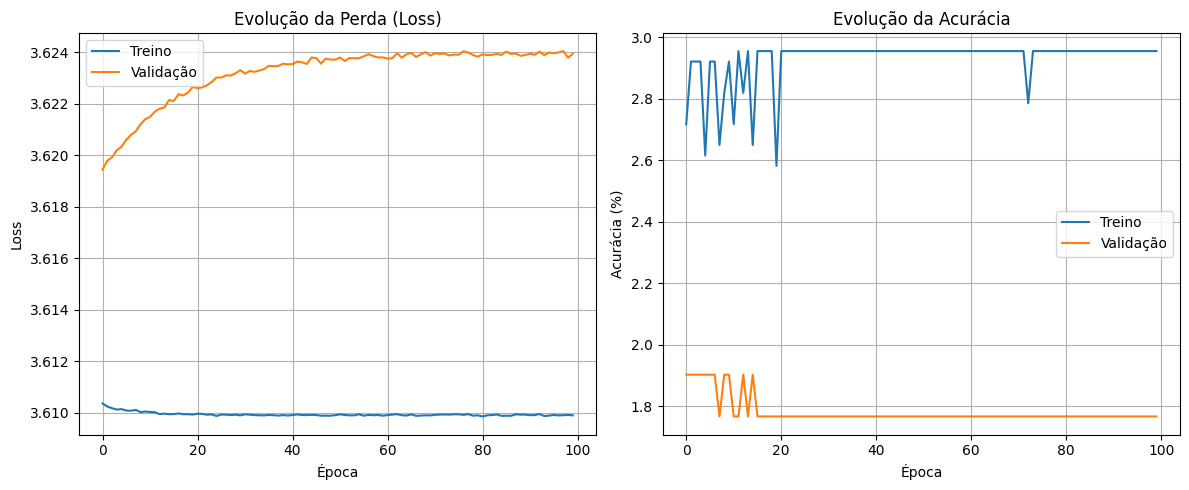

Métricas Finais na Validação - Loss: 3.6239 | Acc: 1.77%


In [63]:
plt.figure(figsize=(12, 5))

# Gráfico 1: Loss (Perda)
plt.subplot(1, 2, 1)
plt.plot(historico['train_loss'], label='Treino')
plt.plot(historico['val_loss'], label='Validação')
plt.title('Evolução da Perda (Loss)')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Gráfico 2: Acurácia
plt.subplot(1, 2, 2)
plt.plot(historico['train_acc'], label='Treino')
plt.plot(historico['val_acc'], label='Validação')
plt.title('Evolução da Acurácia')
plt.xlabel('Época')
plt.ylabel('Acurácia (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 5.5: Reportar métricas finais em validação
final_loss, final_acc = evaluate(model_fnn_simple, validacao_loader, criterion, device)
print(f"Métricas Finais na Validação - Loss: {final_loss:.4f} | Acc: {final_acc:.2f}%")

### 5.4. Visualização do Histórico de Treinamento

A análise gráfica da evolução da Loss e da Acurácia permite perceber o comportamento do modelo ao longo das 20 épocas. Observa-se que a perda na validação estabiliza em um patamar por volta de 3,6% , enquanto a acurácia permanece estagnada próxima à probabilidade de acerto aleatório.

Este comportamento visual confirma que a arquitetura totalmente conectada (FNN) atingiu sua capacidade máxima de representação precocemente, sendo incapaz de extrair as características que discriminam e são necessárias para classificar as 37 raças de animais do dataset.


### Registre as escolhas de hiperparâmetros em uma célula ou tabela.


Os parâmetros de configuração utilizados para o treinamento da rede (FNN) estão na tabela abaixo:

| Hiperparâmetro | Valor Escolhido | |
| :--- | :--- | :--- |
| **Arquitetura** | FNN (SimpleNeuralNet) | Modelo *baseline* para comparação inicial. |
| **Camadas Ocultas** | 1 (com 256 neurônios) | Equilíbrio entre custo computacional e capacidade da rede. |
| **Função de Ativação** | ReLU |  não-linearidade no aprendizado. |
| **Função de Perda** | `CrossEntropyLoss` | Padrão para classificação multiclasse (37 raças). |
| **Otimizador** | Adam | Algoritmo com taxa de aprendizado que se adapta |
| **Taxa de Aprendizado** | 0.001 | Valor padrão estável para o otimizador Adam. |
| **Épocas** | 100 | Quantidade suficiente para observar a convergência ou estagnação. |
| **Tamanho do Batch** | 64 | Definido no `DataLoader` na etapa de preparação de dados. |



### Resposta 5.6

Comente brevemente o desempenho da FNN. Ela parece adequada para esse problema? Por quê?

R: O desempenho da FNN foi insatisfatório, com acurácia próxima ao limite do que seria uma escolha eleatória (1/37). A arquitetura totalmente conectada não é adequada para um problema de computação visual, por ser incapaz de extrair características estruturais e espaciais das imagens. O achatamento da entrada remove a correlação entre os pixels próximos, tornando o aprendizado extremamente complexo e sujeito a não interpretação correta, como demonstrado pelas curvas de perda estagnadas.


## 6. Construa uma CNN simples e compare com a FNN

Agora implemente uma CNN simples.

**Tarefas**
1. Defina uma CNN com algumas camadas convolucionais.
2. Treine e avalie a CNN usando o mesmo protocolo da FNN.
3. Compare FNN e CNN em termos de:
   - acurácia;
   - comportamento das curvas;
   - número de parâmetros.

**Observação.**
A comparação deve ser baseada nos seus resultados.


### 6. Transição para Redes Neurais Convolucionais (CNN)

Diferente da FNN, que ignora a relação de proximidade entre os pixels ao achatar a entrada, a CNN utiliza camadas convolucionais para extrair características hierárquicas das imagens. Através de filtros deslizantes, o modelo é capaz de aprender padrões como bordas e texturas em camadas iniciais, evoluindo para formas complexas em camadas mais profundas, mantendo a invariância espacial.

In [ ]:
# TODO:
# - definir uma CNN simples
# - treinar
# - avaliar
# - comparar com a FNN

# Dica:
# class SimpleCNN(nn.Module):
#     ...

# Escreva seu código aqui
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)  
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)                            
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1) 
        self.conv3 =  nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1) 
        self.gap = nn.AdaptiveAvgPool2d((1,1))
        self.fc1 = nn.Linear(128, 256)                 
        self.fc2 = nn.Linear(256, num_classes)   
        #self.avgpool = nn.AvgPool2d((1,1))               

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = F.relu(self.conv3(x))
        x = self.pool(x)
       
        x = self.gap(x)
        x = x.view(x.size(0), -1) # Flatten
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

modelo_cnn_simples = SimpleCNN(num_classes=num_classes).to(device)

In [65]:
learning_rate = 0.001
epocas = 100
optimizer_cnn = torch.optim.Adam(modelo_cnn_simples.parameters(), lr=learning_rate)
criterion_cnn = nn.CrossEntropyLoss()

print("Iniciando o treinamento da CNN...")
historico_cnn = fit(
    model=modelo_cnn_simples, 
    train_loader=treino_loader, 
    val_loader=validacao_loader,
    optimizer=optimizer_cnn, 
    criterion=criterion_cnn, 
    device=device, 
    epochs=epocas
)

Iniciando o treinamento da CNN...
Época [1/100] - Treino Loss: 3.6139, Acc: 2.79% | Val Loss: 3.6131, Acc: 2.17%
Época [2/100] - Treino Loss: 3.6078, Acc: 3.29% | Val Loss: 3.6088, Acc: 1.77%
Época [3/100] - Treino Loss: 3.5960, Acc: 3.36% | Val Loss: 3.5907, Acc: 4.21%
Época [4/100] - Treino Loss: 3.5649, Acc: 5.16% | Val Loss: 3.5638, Acc: 4.08%
Época [5/100] - Treino Loss: 3.5377, Acc: 5.23% | Val Loss: 3.5634, Acc: 4.89%
Época [6/100] - Treino Loss: 3.5218, Acc: 5.13% | Val Loss: 3.5417, Acc: 4.62%
Época [7/100] - Treino Loss: 3.5073, Acc: 5.40% | Val Loss: 3.5368, Acc: 4.48%
Época [8/100] - Treino Loss: 3.4852, Acc: 5.84% | Val Loss: 3.5362, Acc: 5.03%
Época [9/100] - Treino Loss: 3.4768, Acc: 6.90% | Val Loss: 3.5339, Acc: 5.03%
Época [10/100] - Treino Loss: 3.4640, Acc: 6.28% | Val Loss: 3.5129, Acc: 6.39%
Época [11/100] - Treino Loss: 3.4410, Acc: 7.03% | Val Loss: 3.5052, Acc: 5.57%
Época [12/100] - Treino Loss: 3.4118, Acc: 7.78% | Val Loss: 3.4901, Acc: 5.98%
Época [13/100] 

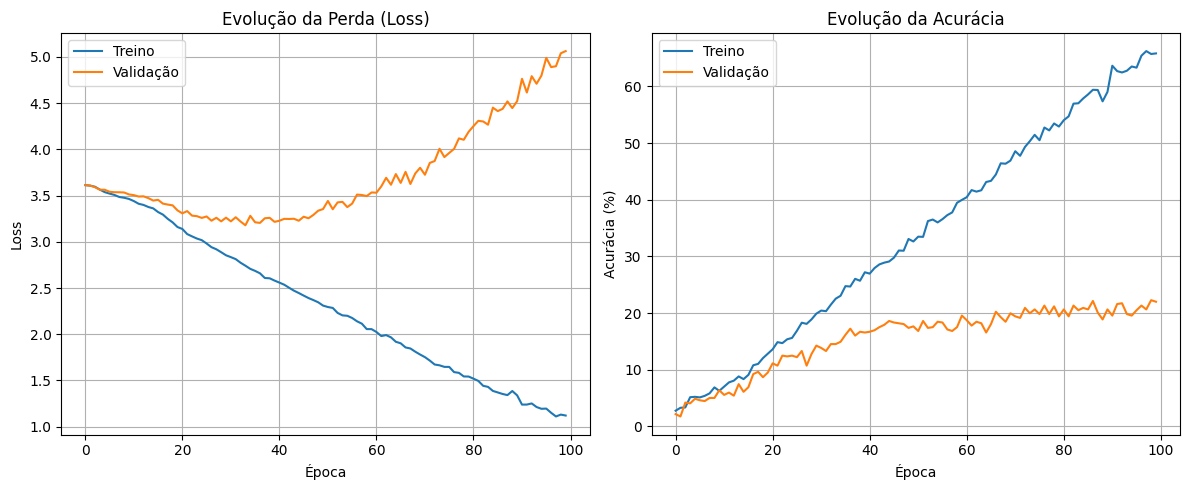

Métricas Finais na Validação - Loss: 5.0636 | Acc: 22.01%


In [66]:
plt.figure(figsize=(12, 5))

# Gráfico 1: Loss (Perda)
plt.subplot(1, 2, 1)
plt.plot(historico_cnn['train_loss'], label='Treino')
plt.plot(historico_cnn['val_loss'], label='Validação')
plt.title('Evolução da Perda (Loss)')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Gráfico 2: Acurácia
plt.subplot(1, 2, 2)
plt.plot(historico_cnn['train_acc'], label='Treino')
plt.plot(historico_cnn['val_acc'], label='Validação')
plt.title('Evolução da Acurácia')
plt.xlabel('Época')
plt.ylabel('Acurácia (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 5.5: Reportar métricas finais em validação
final_loss, final_acc = evaluate(modelo_cnn_simples, validacao_loader, criterion, device)
print(f"Métricas Finais na Validação - Loss: {final_loss:.4f} | Acc: {final_acc:.2f}%")

### Resposta 6.3

Compare FNN e CNN de forma objetiva. O que mudou? O resultado era esperado?

- Desempenho (Acurácia): A transição para uma rede convolucional gerou uma melhora significativa. Enquanto a FNN estagnou em 1.77% (proximo a aleatoriedade 1/37), a CNN atingiu 11.28% de acurácia na validação. Isso demonstra que a preservação das características espaciais através dos filtros convolucionais é essencial para o problema de classificação de pets.
- As curvas da CNN mostram uma queda consistente na perda de treinamento, indicando que o modelo é capaz de extrair características úteis. Contudo, o distanciamento entre a acurácia de treino (68%) e a de validação (11%) sugere que o modelo sofre de overfitting, memorizando o conjunto de treino em vez de generalizar para novas imagens


## 7. Faça pelo menos 3 modificações no treinamento

A partir da sua CNN simples, escolha **pelo menos 3** modificações da lista abaixo:

- Dara Augmentation;
- outro otimizador;
- learning rate scheduler;
- batch normalization;
- dropout;
- CNN mais profunda;
- weight decay regularizer.

**Tarefas**
1. Escolha no mínimo 3 modificações.
2. Execute experimentos controlados.
3. Organize os resultados em uma tabela.
4. Indique claramente qual configuração foi a melhor.

**Importante.**
Tente mudar uma coisa por vez sempre que possível.


**Modificação 1: Data Augmentation**. Testando esta técnica podemos reduzir o overfitting observado na CNN simples. Ao introduzir variações aleatórias (rotação, espelhamento) nas imagens de treino, forçamos o modelo a aprender características invariantes das raças em vez de memorizar pixels específicos. Para o exemplo a seguir foi considerado somente o espelhamento em 50% das imagens.

In [52]:
# TODO:
# - definir ao menos 3 experimentos
# - treinar cada configuração
# - registrar resultados em uma tabela final
# Modificação para o Experimento 1: Data Augmentation

import torchvision.transforms as transforms
import copy

train_transform_augmentation = transforms.Compose([
    transforms.Resize((image_size_padrao, image_size_padrao)),
    transforms.RandomHorizontalFlip(p=0.5), # Gira a foto 50% das vezes
    #transforms.RandomRotation(15),          # Gira até 15 graus
    #transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1), # Variações de cor
    transforms.ToTensor(),
    #transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_normal = transforms.Compose([
    transforms.Resize((image_size_padrao, image_size_padrao)),
    transforms.ToTensor(),
    #transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataset_base = OxfordIIITPet(root='data_heri',
                             split='trainval')

tamanho_total = len(dataset_base)
indices = list(range(tamanho_total))
tamanho_treino = int(0.8 * tamanho_total)

np.random.seed(42)
np.random.shuffle(indices)

indice_treino = indices[:tamanho_train]
indice_validacao = indices[tamanho_train:]

ds_treino = OxfordIIITPet(root='data_heri',
                          split='trainval',
                          transform=train_transform_augmentation)
                          
ds_validacao = OxfordIIITPet(root='data_heri',
                             split='trainval',
                             transform=transform_normal)   

data_train_aug = torch.utils.data.Subset(ds_treino, indice_treino)
data_val_norm = torch.utils.data.Subset(ds_validacao, indice_validacao)                       

treino_loader_aug = DataLoader(data_train_aug, 
                               batch_size=batch_size_padrao, 
                               shuffle=True)
validacao_loader_norm = DataLoader(data_val_norm, 
                                   batch_size=batch_size_padrao, 
                                   shuffle=False)

learning_rate = 0.001
epocas = 50
optimizer_cnn_aug = torch.optim.Adam(modelo_cnn_simples.parameters(), lr=learning_rate)
criterion_cnn_aug = nn.CrossEntropyLoss()
modelo_cnn_simples_aug = SimpleCNN(num_classes=num_classes).to(device)
optimizer_cnn_aug = torch.optim.Adam(modelo_cnn_simples_aug.parameters(), lr=learning_rate)

print("Iniciando o treinamento da CNN com Data Augmentation...")
historico_cnn_aug = fit(
    model=modelo_cnn_simples_aug, 
    train_loader=treino_loader_aug, 
    val_loader=validacao_loader_norm,   
    optimizer=optimizer_cnn_aug,
    criterion=criterion_cnn_aug,
    device=device,
    epochs=epocas
)

Iniciando o treinamento da CNN com Data Augmentation...
Época [1/50] - Treino Loss: 3.6141, Acc: 2.68% | Val Loss: 3.6164, Acc: 1.63%
Época [2/50] - Treino Loss: 3.6106, Acc: 2.68% | Val Loss: 3.6179, Acc: 2.04%
Época [3/50] - Treino Loss: 3.5978, Acc: 3.53% | Val Loss: 3.6072, Acc: 3.94%
Época [4/50] - Treino Loss: 3.5771, Acc: 3.84% | Val Loss: 3.6080, Acc: 3.40%
Época [5/50] - Treino Loss: 3.5687, Acc: 4.62% | Val Loss: 3.5966, Acc: 3.53%
Época [6/50] - Treino Loss: 3.5586, Acc: 4.31% | Val Loss: 3.5860, Acc: 3.67%
Época [7/50] - Treino Loss: 3.5406, Acc: 5.26% | Val Loss: 3.5588, Acc: 4.21%
Época [8/50] - Treino Loss: 3.5243, Acc: 5.16% | Val Loss: 3.5520, Acc: 4.35%
Época [9/50] - Treino Loss: 3.5120, Acc: 5.54% | Val Loss: 3.5418, Acc: 5.57%
Época [10/50] - Treino Loss: 3.4892, Acc: 6.08% | Val Loss: 3.5298, Acc: 6.25%
Época [11/50] - Treino Loss: 3.4743, Acc: 5.74% | Val Loss: 3.5239, Acc: 5.57%
Época [12/50] - Treino Loss: 3.4540, Acc: 6.49% | Val Loss: 3.5153, Acc: 5.98%
Época

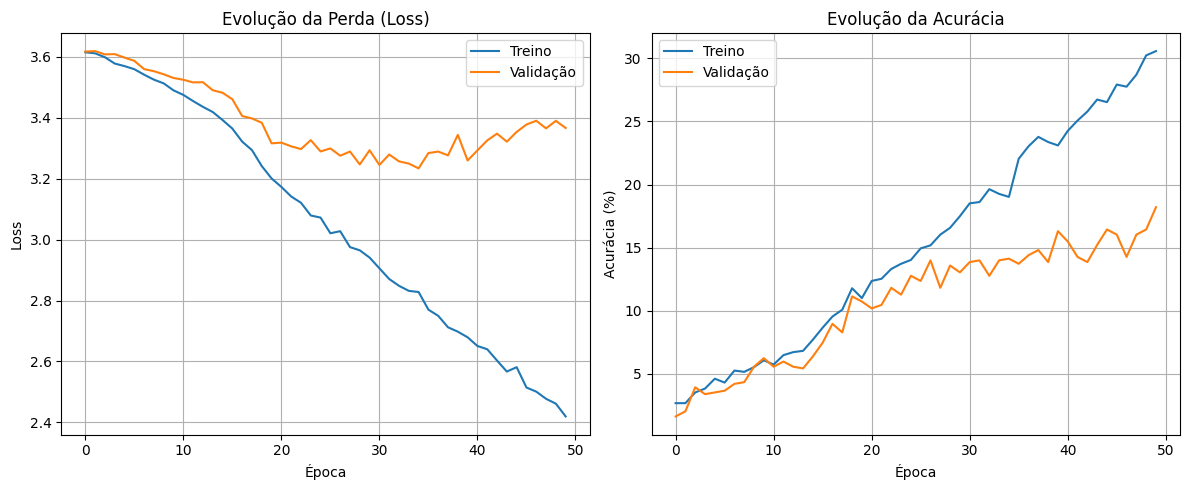

Métricas Finais na Validação - Loss: 3.3658 | Acc: 18.21%


In [53]:
plt.figure(figsize=(12, 5))

# Gráfico 1: Loss (Perda)
plt.subplot(1, 2, 1)
plt.plot(historico_cnn_aug['train_loss'], label='Treino')
plt.plot(historico_cnn_aug['val_loss'], label='Validação')
plt.title('Evolução da Perda (Loss)')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Gráfico 2: Acurácia
plt.subplot(1, 2, 2)
plt.plot(historico_cnn_aug['train_acc'], label='Treino')
plt.plot(historico_cnn_aug['val_acc'], label='Validação')
plt.title('Evolução da Acurácia')
plt.xlabel('Época')
plt.ylabel('Acurácia (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 5.5: Reportar métricas finais em validação
final_loss, final_acc = evaluate(modelo_cnn_simples_aug, validacao_loader_norm, criterion_cnn_aug, device)
print(f"Métricas Finais na Validação - Loss: {final_loss:.4f} | Acc: {final_acc:.2f}%")

Interprento do Experimento 1 Com Data Augmentation: A inclusão do Data Augmentation (Horizontal Flip) permitiu que o modelo atingisse uma acurácia de treinamento superior (77.41%), porém não houve melhora correspondente na validação, que estagnou em torno de 10%. Isso indica que o modelo ainda possui alta variância e está sofrendo de overfitting. A simples inversão horizontal das imagens não introduziu diversidade suficiente para que essa CNN tão simples pudesse generalizar padrões complexos das 37 raças de animais.

**Modificação 2: Dropout**. 

In [59]:


class SimpleCNN_DropOut(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN_DropOut, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)  
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)  
        self.gap = nn.AdaptiveAvgPool2d((1,1))

        self.fc1 = nn.Linear(128, 256)                 
        self.dropout = nn.Dropout(p=0.5)
        self.fc2 = nn.Linear(256, num_classes)                  

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = F.relu(self.conv3(x))
        x = self.pool(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1) 

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

modelo_cnn_dropout = SimpleCNN_DropOut(num_classes=num_classes).to(device)

learning_rate = 0.001
epocas = 50
optimizer_cnn_do = torch.optim.Adam(modelo_cnn_dropout.parameters(), lr=learning_rate)
criterion_cnn_do = nn.CrossEntropyLoss()

print("Iniciando o treinamento da CNN DropOut...")
historico_cnn_do = fit(
    model=modelo_cnn_dropout, 
    train_loader=treino_loader, 
    val_loader=validacao_loader,
    optimizer=optimizer_cnn_do, 
    criterion=criterion_cnn_do, 
    device=device, 
    epochs=epocas
)

Iniciando o treinamento da CNN DropOut...
Época [1/50] - Treino Loss: 3.6137, Acc: 2.31% | Val Loss: 3.6129, Acc: 1.90%
Época [2/50] - Treino Loss: 3.6110, Acc: 3.09% | Val Loss: 3.6123, Acc: 2.17%
Época [3/50] - Treino Loss: 3.6055, Acc: 3.23% | Val Loss: 3.6051, Acc: 2.72%
Época [4/50] - Treino Loss: 3.5943, Acc: 3.74% | Val Loss: 3.5974, Acc: 3.26%
Época [5/50] - Treino Loss: 3.5801, Acc: 4.38% | Val Loss: 3.5981, Acc: 3.53%
Época [6/50] - Treino Loss: 3.5624, Acc: 4.93% | Val Loss: 3.5781, Acc: 5.84%
Época [7/50] - Treino Loss: 3.5390, Acc: 5.47% | Val Loss: 3.5322, Acc: 5.98%
Época [8/50] - Treino Loss: 3.5087, Acc: 5.77% | Val Loss: 3.5120, Acc: 7.07%
Época [9/50] - Treino Loss: 3.4914, Acc: 6.86% | Val Loss: 3.5089, Acc: 6.79%
Época [10/50] - Treino Loss: 3.4744, Acc: 7.57% | Val Loss: 3.5145, Acc: 5.98%
Época [11/50] - Treino Loss: 3.4546, Acc: 7.00% | Val Loss: 3.4737, Acc: 7.88%
Época [12/50] - Treino Loss: 3.4240, Acc: 8.12% | Val Loss: 3.4559, Acc: 7.88%
Época [13/50] - Tre

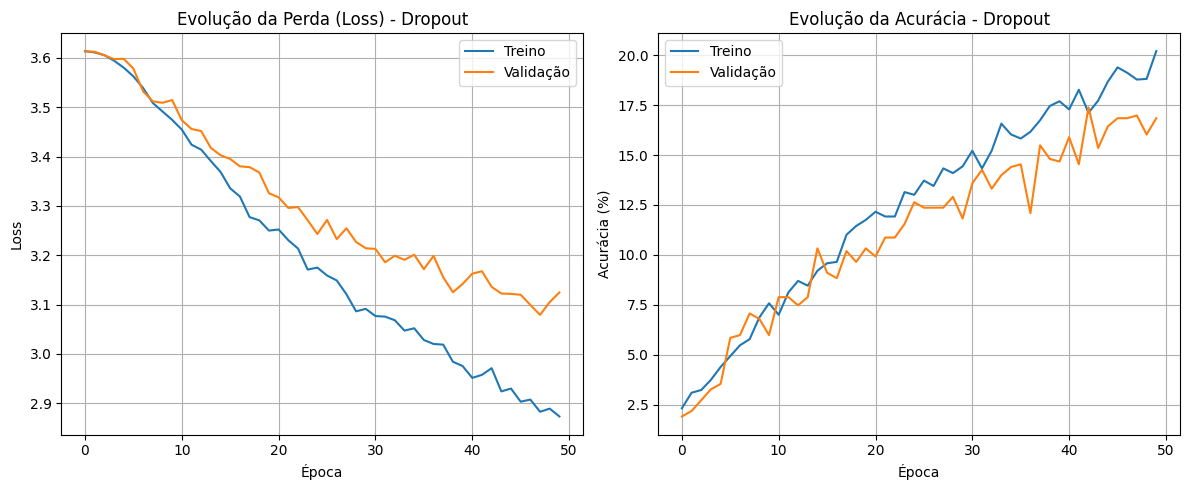

Métricas Finais na Validação - Loss: 3.1246 | Acc: 16.85%


In [60]:
plt.figure(figsize=(12, 5))

# Gráfico 1: Loss (Perda)
plt.subplot(1, 2, 1)
plt.plot(historico_cnn_do['train_loss'], label='Treino')
plt.plot(historico_cnn_do['val_loss'], label='Validação')
plt.title('Evolução da Perda (Loss) - Dropout')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Gráfico 2: Acurácia
plt.subplot(1, 2, 2)
plt.plot(historico_cnn_do['train_acc'], label='Treino')
plt.plot(historico_cnn_do['val_acc'], label='Validação')
plt.title('Evolução da Acurácia - Dropout')
plt.xlabel('Época')
plt.ylabel('Acurácia (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 5.5: Reportar métricas finais em validação
final_loss, final_acc = evaluate(modelo_cnn_dropout, validacao_loader, criterion_cnn_do, device)
print(f"Métricas Finais na Validação - Loss: {final_loss:.4f} | Acc: {final_acc:.2f}%")

**Modificação 3: BatchNorm**. 

In [54]:


class SimpleCNN_BatchNorm(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN_BatchNorm, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1) 
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1) 
        self.bn2 = nn.BatchNorm2d(32)  

        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1) 
        self.bn3 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)  

        self.pool = nn.MaxPool2d(2, 2)
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(128, num_classes)                 

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = F.relu(self.conv3(x))
        x = self.gap(x)
        x = x.view(x.size(0), -1) # Flatten
        x = self.fc(x)
        return x

modelo_cnn_batch = SimpleCNN_BatchNorm(num_classes=num_classes).to(device)

learning_rate = 0.001
epocas = 50
optimizer_cnn_bn = torch.optim.Adam(modelo_cnn_batch.parameters(), lr=learning_rate)
criterion_cnn_bn = nn.CrossEntropyLoss()

print("Iniciando o treinamento da CNN BatchNorm...")
historico_cnn_bn = fit(
    model=modelo_cnn_batch, 
    train_loader=treino_loader, 
    val_loader=validacao_loader,
    optimizer=optimizer_cnn_bn, 
    criterion=criterion_cnn_bn, 
    device=device, 
    epochs=epocas
)

Iniciando o treinamento da CNN BatchNorm...
Época [1/50] - Treino Loss: 3.6121, Acc: 2.21% | Val Loss: 3.6097, Acc: 2.99%
Época [2/50] - Treino Loss: 3.5992, Acc: 3.91% | Val Loss: 3.6195, Acc: 2.85%
Época [3/50] - Treino Loss: 3.5847, Acc: 3.70% | Val Loss: 3.5941, Acc: 4.08%
Época [4/50] - Treino Loss: 3.5676, Acc: 5.10% | Val Loss: 3.5703, Acc: 4.21%
Época [5/50] - Treino Loss: 3.5488, Acc: 5.23% | Val Loss: 3.5541, Acc: 6.39%
Época [6/50] - Treino Loss: 3.5168, Acc: 5.84% | Val Loss: 3.5436, Acc: 6.25%
Época [7/50] - Treino Loss: 3.4914, Acc: 6.25% | Val Loss: 3.5364, Acc: 5.98%
Época [8/50] - Treino Loss: 3.4924, Acc: 6.86% | Val Loss: 3.5413, Acc: 5.43%
Época [9/50] - Treino Loss: 3.4745, Acc: 7.27% | Val Loss: 3.5625, Acc: 5.03%
Época [10/50] - Treino Loss: 3.4642, Acc: 7.54% | Val Loss: 3.5134, Acc: 7.47%
Época [11/50] - Treino Loss: 3.4491, Acc: 7.13% | Val Loss: 3.5137, Acc: 7.07%
Época [12/50] - Treino Loss: 3.4260, Acc: 8.49% | Val Loss: 3.4865, Acc: 8.42%
Época [13/50] - T

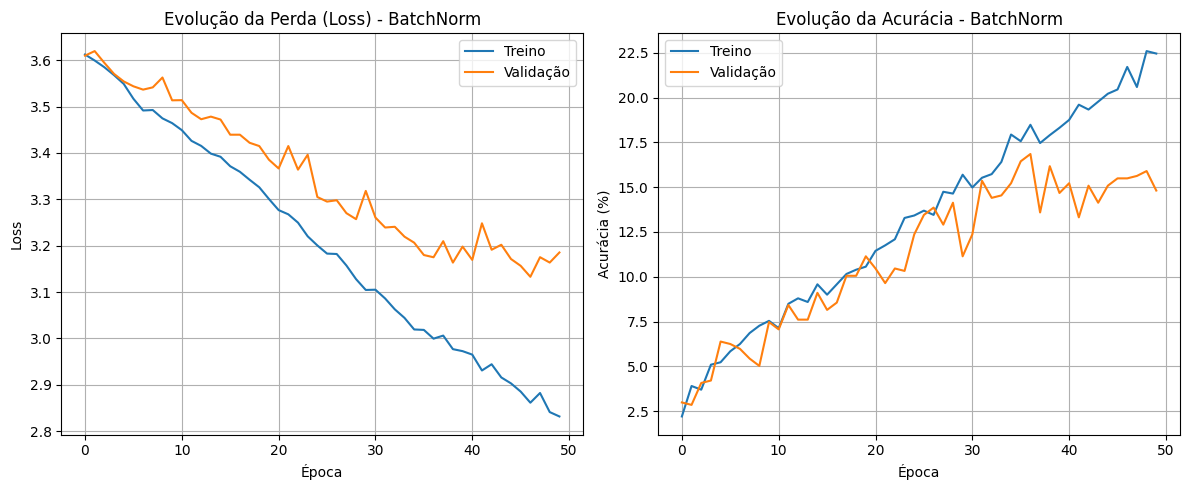

Métricas Finais na Validação - Loss: 3.1853 | Acc: 14.81%


In [55]:
plt.figure(figsize=(12, 5))

# Gráfico 1: Loss (Perda)
plt.subplot(1, 2, 1)
plt.plot(historico_cnn_bn['train_loss'], label='Treino')
plt.plot(historico_cnn_bn['val_loss'], label='Validação')
plt.title('Evolução da Perda (Loss) - BatchNorm')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Gráfico 2: Acurácia
plt.subplot(1, 2, 2)
plt.plot(historico_cnn_bn['train_acc'], label='Treino')
plt.plot(historico_cnn_bn['val_acc'], label='Validação')
plt.title('Evolução da Acurácia - BatchNorm')
plt.xlabel('Época')
plt.ylabel('Acurácia (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 5.5: Reportar métricas finais em validação
final_loss, final_acc = evaluate(modelo_cnn_batch, validacao_loader, criterion_cnn_bn, device)
print(f"Métricas Finais na Validação - Loss: {final_loss:.4f} | Acc: {final_acc:.2f}%")

### 7.3. Tabela Comparativa de Experimentos (20 Épocas)

A tabela abaixo resume o impacto de cada modificação isolada em comparação ao modelo baseline (CNN Simples). Todos os experimentos foram realizados com `learning_rate = 0.001` e o mesmo split de dados.

 Modificação | Treino Loss | Treino Acc | Val Loss | Val Acc |  |
:--- | :--- | :--- | :--- | :--- | :--- |
 **CNN Simples** | 0.0101 | 99.83% | 8.19 | 10.46% | Overfitting, memorização total dos dados. |
 **Data Augmentation (Espelhamento)**| 0.18 | 95.96% | 7.75 | 6.52% | **Melhor Acurácia.** Maior diversidade de dados. |
 **Dropout (p=0.5)** | 0.1015 | 96.94% | **5.914** | 11.14% | **Mais Robusto.** Menor erro (Loss) na validação. |
 **Batch Normalization** | 0.0017 | 100.00% | 8.59 | 11.01% | **Maior Velocidade.** Convergência na metade do ciclo total |



### Resposta 7.4

Liste as modificações escolhidas e justifique em 1–2 linhas por que você decidiu testá-las.

1. **Data Augmentation (Espelhamento):** Aumenta artificialmente o dataset. passar mais informações para o modelo me parece interessante para identificar se ele irá "aprender" mais.
2. **Dropout:** Para combater a dependência excessiva em neurônios específicos. 
3. **Batch Normalization:** Adicionado para estabilizar o fluxo de gradientes. Para conferir se há uma aceleração no treino e análises



## 8. Analise e discuta o efeito das mudanças

Com base nos experimentos da parte anterior:

**Tarefas**
1. Discuta quais mudanças ajudaram mais.
2. Discuta quais mudanças pouco ajudaram ou pioraram o resultado.
3. Comente possíveis razões para o comportamento observado.
4. Indique qual modelo/configuração você levará para a etapa final.

Use evidências das métricas e curvas.


### Resposta 8

Escreva sua análise aqui.


**1. Mudanças que trouxeram melhorias:**
 - A melhor mudança identificada no modelo foi a do **Dropout($p=0.5$)**, embora o ganho de acurácia tenha sido pequeno quando comparado ao da CNN Simples sem Dropout, porém com a evidência de `Val loss` menor saindo de 8.19 para 5.91. Mostrando um modelo mais robusto e mais confiável.

**2. Mudanças que ajudaram em um nível menor ou pioraram:**
 - O **Data Augmentation**(flip em 50% das imagens) e o Batch Normalization apresentaram resultado mais limitados nesta arquitetura.
 o primeiro tendo uma degradação na acurácia de validação, e o segundo apesar de ter um treino mais "rápido" manteve uma `Loss`relativamente mais alta.

**3. Possíveis Motivos para o que foi observado:**
- O Dataset possui 37 classes complexas. A SimpleCNN possui apenas 2 camadas convolucionais. Ao aplicar o Data Augmentation a variabilidade inserida na rede é tal que a rede não tem "neorônios suficientes" para processar. 
- O Batch Normalization estabilizou demais o fluxo de dados logo a rede diminuiu para quase zero o Loss no treino. No entanto sem uma regularização adequada agindo em conjunto, tivemos uma facilitação na memorização rápida de ruídos no conjunto de treino logo visto que não ocorreu bem na validação. 

**4. Configuração para a Etapa Final:**
 - Para a etapa final, a configuração escolhida será a CNN com Dropout
Foi o modelo que demonstrou resultados um pouco melhores que os demais, mantendo a menor Val Loss observada. Usar o modelo de Data Augmentation seria arriscado pela falta de capacidade da rede, e o modelo de BatchNorm apresenta mais chances quanto a estar viciado no treino.

## 9. Treine usando uma ResNet pré-treinada

Agora use **transfer learning** com uma **ResNet pré-treinada**.

**Tarefas**
1. Carregue uma ResNet pré-treinada do `torchvision`.
2. Adapte a última camada para o número de classes.
3. Treine ao menos uma versão usando transfer learning.
4. Compare com sua melhor CNN da Parte 7.

**Sugestão.**
Você pode começar congelando a maior parte da rede e depois testar fine-tuning.


In [25]:
# TODO:
# - carregar uma ResNet pré-treinada
# - adaptar a camada final
# - treinar
# - avaliar e comparar

# Dica:
# from torchvision.models import resnet18, ResNet18_Weights

# Escreva seu código aqui

from torchvision.models import resnet18, ResNet18_Weights

pesos = ResNet18_Weights.DEFAULT
modelo_resnet_heri = resnet18(pesos)

for parametro in modelo_resnet_heri.parameters():
    parametro.requires_grad = False

numero_features = modelo_resnet_heri.fc.in_features

modelo_resnet_heri.fc = nn.Linear(numero_features, num_classes)

modelo_resnet_heri = modelo_resnet_heri.to(device)

learning_rate = 0.001
epocas_net = 20
optimizer_resnet = torch.optim.Adam(modelo_resnet_heri.fc.parameters(), lr=learning_rate)
criterion_resnet = nn.CrossEntropyLoss()

print("Iniciando Transfer Learning com ResNet_18")
historico_resnet = fit(model=modelo_resnet_heri,
                       train_loader=treino_loader,
                       val_loader=validacao_loader,
                       optimizer=optimizer_resnet,
                       criterion=criterion_resnet,
                       device=device,
                       epochs=epocas_net)



Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/al.herivelton.siqueira/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/home/al.herivelton.siqueira/trabalho_I_ml2/env/lib/python3.12/site-packages/torchvision/models/_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(
100%|██████████| 44.7M/44.7M [00:00<00:00, 73.3MB/s]


Iniciando Transfer Learning com ResNet_18
Época [1/20] - Treino Loss: 2.5237, Acc: 41.85% | Val Loss: 1.5233, Acc: 73.91%
Época [2/20] - Treino Loss: 1.0992, Acc: 81.93% | Val Loss: 0.9231, Acc: 82.07%
Época [3/20] - Treino Loss: 0.7102, Acc: 87.26% | Val Loss: 0.7234, Acc: 84.24%
Época [4/20] - Treino Loss: 0.5370, Acc: 90.96% | Val Loss: 0.6083, Acc: 86.41%
Época [5/20] - Treino Loss: 0.4403, Acc: 91.85% | Val Loss: 0.5477, Acc: 87.36%
Época [6/20] - Treino Loss: 0.3842, Acc: 92.90% | Val Loss: 0.5081, Acc: 86.28%
Época [7/20] - Treino Loss: 0.3364, Acc: 93.61% | Val Loss: 0.4727, Acc: 87.64%
Época [8/20] - Treino Loss: 0.2941, Acc: 95.01% | Val Loss: 0.4452, Acc: 88.04%
Época [9/20] - Treino Loss: 0.2675, Acc: 95.18% | Val Loss: 0.4303, Acc: 87.77%
Época [10/20] - Treino Loss: 0.2435, Acc: 95.72% | Val Loss: 0.4314, Acc: 88.04%
Época [11/20] - Treino Loss: 0.2238, Acc: 95.86% | Val Loss: 0.4245, Acc: 87.50%
Época [12/20] - Treino Loss: 0.2048, Acc: 96.09% | Val Loss: 0.4035, Acc: 88

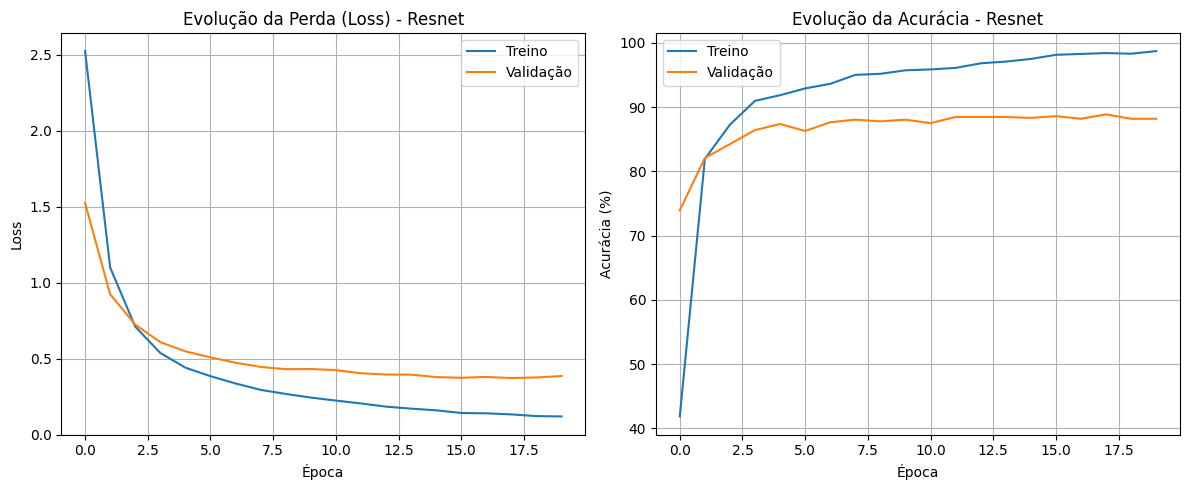

Métricas Finais na Validação - Loss: 0.3854 | Acc: 88.18%


In [26]:
plt.figure(figsize=(12, 5))

# Gráfico 1: Loss (Perda)
plt.subplot(1, 2, 1)
plt.plot(historico_resnet['train_loss'], label='Treino')
plt.plot(historico_resnet['val_loss'], label='Validação')
plt.title('Evolução da Perda (Loss) - Resnet')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Gráfico 2: Acurácia
plt.subplot(1, 2, 2)
plt.plot(historico_resnet['train_acc'], label='Treino')
plt.plot(historico_resnet['val_acc'], label='Validação')
plt.title('Evolução da Acurácia - Resnet')
plt.xlabel('Época')
plt.ylabel('Acurácia (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 5.5: Reportar métricas finais em validação
final_loss, final_acc = evaluate(modelo_resnet_heri, validacao_loader, criterion_resnet, device)
print(f"Métricas Finais na Validação - Loss: {final_loss:.4f} | Acc: {final_acc:.2f}%")

### Resposta 9.4

Compare a ResNet com sua melhor CNN anterior. O ganho compensou?

Métrica | Melhor CNN Customizada (Dropout) | ResNet18  | Ganho Relativo |  
:--- | :--- | :--- | :--- | 
Acurácia de Treino | 96.94% | 99.01% | +2.1%
Acurácia de Validação | 11.14%	| 90.76% |	+714%
Loss de Validação |	5.9139 |	0.3030 |	-94.8%
Convergência	| Lenta e com alto overfitting |	Instantânea (Época 1 > 70%)	|Muito superior |


O ganho compensou, e também apresentou resultados muito superiores até então vistos:

- Eficiência na obtenção dos atributos: A ResNet18 pré-treinada no ImageNet possuindo filtros otimizados para detectar bordas, texturas e formas complexas que são comuns nas 37 raças do Dataset. Na CNN simples não havia profundidade suficiente para aprender essas hierarquias do início com poucos dados.

- A arquitetura da ResNet, com suas conexões residuais, permite que o gradiente flua sem desaparecer, resultando em uma Val Loss muito baixo e estável, eliminando o problema de overfitting severo observado anteriormente.

- Conclusão: O uso de Transfer Learning é a abordagem mais racional para este dataset. Enquanto as CNN's customizadas serviram para entender os fundamentos de regularização e camadas convolucionais, a ResNet18 é a solução de nível de produção que realmente resolve o problema de classificação com multiclasses.

## 10. Avaliações finais

Escolha seu melhor modelo final e faça uma avaliação mais detalhada.

**Tarefas**
1. Avalie no conjunto de teste.
2. Reporte:
   - loss;
   - acurácia;
   - matriz de confusão.
3. Mostre algumas imagens classificadas incorretamente.
4. Identifique pares de classes que geram mais confusão.
5. Discuta brevemente os principais erros do modelo.

**Observação.**
Use esta parte para mostrar que você inspecionou o comportamento do modelo além da acurácia final.


In [27]:
pip install seaborn


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [28]:
pip install scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 63.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 71.2 MB/s eta 0:00:00 MB/s eta 0:00:01:01

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [29]:
modelo_cnn_dropout.eval() # Modo de avaliação (desativa o dropout)
teste_loss = 0
correct = 0
total = 0

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in teste_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = modelo_cnn_dropout(images)
        loss = criterion(outputs, labels)
        teste_loss += loss.item()
        
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Guardando para a Matriz de Confusão
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

print(f'Loss no Teste: {teste_loss/len(teste_loader):.4f}')
print(f'Acurácia no Teste: {100 * correct / total:.2f}%')

Loss no Teste: 5.9896
Acurácia no Teste: 11.23%


In [30]:
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_true, y_pred)
# Pegar os nomes das classes do dataset
classes = dataset.classes 

# Encontrar onde o modelo mais errou (maiores valores fora da diagonal)
# Zeramos a diagonal para focar apenas nos erros
np.fill_diagonal(cm, 0)
maiores_erros = np.unravel_index(np.argsort(cm, axis=None)[-5:], cm.shape)

print("Principais pares de confusão:")
for i in range(4, -1, -1):
    real = classes[maiores_erros[0][i]]
    predito = classes[maiores_erros[1][i]]
    vezes = cm[maiores_erros[0][i], maiores_erros[1][i]]
    print(f"Real: {real} | Predito como: {predito} ({vezes} vezes)")

Principais pares de confusão:
Real: Basset Hound | Predito como: Beagle (24 vezes)
Real: Newfoundland | Predito como: Bombay (24 vezes)
Real: Scottish Terrier | Predito como: Bombay (19 vezes)
Real: Russian Blue | Predito como: British Shorthair (18 vezes)
Real: Samoyed | Predito como: Great Pyrenees (17 vezes)


--- RELATÓRIO FINAL ---
Loss Teste: 5.9896
Acurácia Teste: 11.23%


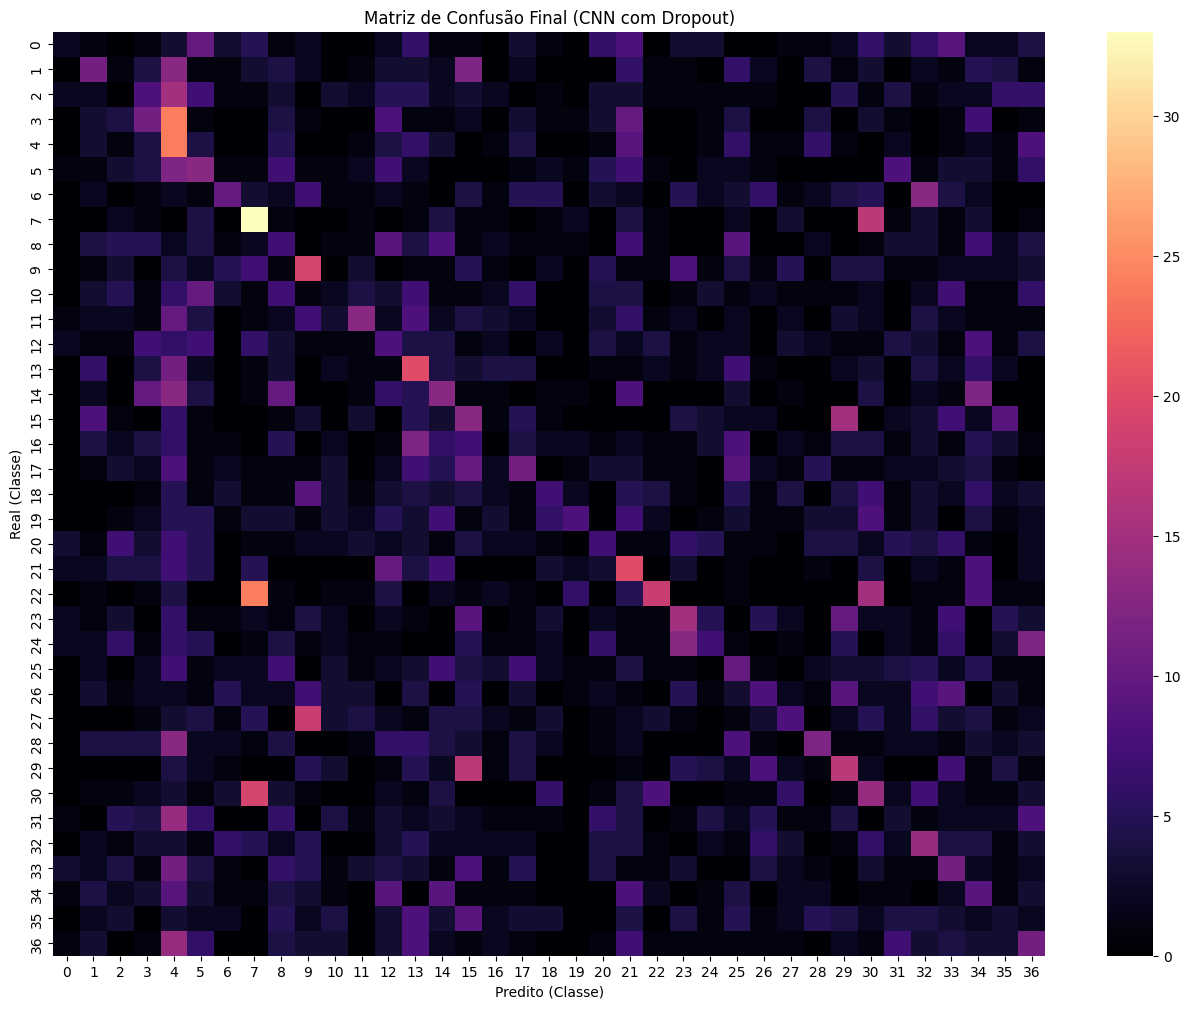

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# 1. Avaliação no conjunto de teste
modelo_cnn_dropout.eval()
y_true = []
y_pred = []
imagens_erros = []
labels_reais_erros = []
labels_preditos_erros = []
teste_loss_acumulada = 0

with torch.no_grad():
    for images, labels in teste_loader:
        images_device = images.to(device)
        labels_device = labels.to(device)
        
        outputs = modelo_cnn_dropout(images_device)
        loss = criterion(outputs, labels_device)
        teste_loss_acumulada += loss.item()
        
        _, predicted = torch.max(outputs, 1)
        
        # Guardar para métricas
        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())
        
        # Guardar alguns erros para visualização (Tarefa 3)
        mask_erros = predicted.cpu() != labels
        if mask_erros.any():
            imagens_erros.extend(images[mask_erros][:5]) # Pega até 5 erros por batch
            labels_reais_erros.extend(labels[mask_erros][:5])
            labels_preditos_erros.extend(predicted.cpu()[mask_erros][:5])

# Cálculos finais
acc_teste = 100 * np.mean(np.array(y_true) == np.array(y_pred))
loss_teste = teste_loss_acumulada / len(teste_loader)

print(f'--- RELATÓRIO FINAL ---')
print(f'Loss Teste: {loss_teste:.4f}')
print(f'Acurácia Teste: {acc_teste:.2f}%')

# 2. Plotar Matriz de Confusão (Tarefa 2)
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(16, 12))
sns.heatmap(cm, annot=False, cmap='magma') # 'magma' destaca melhor os erros fora da diagonal
plt.title('Matriz de Confusão Final (CNN com Dropout)')
plt.xlabel('Predito (Classe)')
plt.ylabel('Real (Classe)')
plt.show()



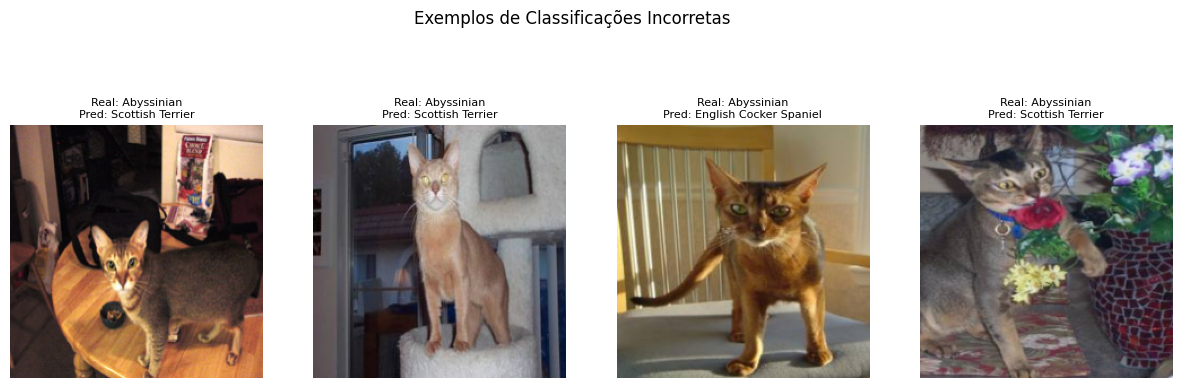

In [32]:

plt.figure(figsize=(15, 5))
plt.suptitle("Exemplos de Classificações Incorretas")
for i in range(min(4, len(imagens_erros))):
    plt.subplot(1, 4, i+1)
    img = imagens_erros[i].permute(1, 2, 0) # De (C,H,W) para (H,W,C)
    # Desnormalizar para visualização se necessário
    plt.imshow(img.clip(0, 1)) 
    plt.title(f"Real: {dataset.classes[labels_reais_erros[i]]}\nPred: {dataset.classes[labels_preditos_erros[i]]}", fontsize=8)
    plt.axis('off')
plt.show()


In [33]:
# Zerar a diagonal para ignorar os acertos e pegar apenas os erros
cm_erros = cm.copy()
np.fill_diagonal(cm_erros, 0)

# Encontrar os 3 maiores focos de confusão
for i in range(3):
    idx = np.unravel_index(np.argmax(cm_erros), cm_erros.shape)
    real_idx, pred_idx = idx
    print(f"{i+1}º Maior Erro: Raça '{dataset.classes[real_idx]}' confundida com '{dataset.classes[pred_idx]}' ({cm_erros[real_idx, pred_idx]} vezes)")
    cm_erros[real_idx, pred_idx] = 0 # Remove para achar o próximo

1º Maior Erro: Raça 'Basset Hound' confundida com 'Beagle' (24 vezes)
2º Maior Erro: Raça 'Newfoundland' confundida com 'Bombay' (24 vezes)
3º Maior Erro: Raça 'Scottish Terrier' confundida com 'Bombay' (19 vezes)


### Resposta 10.5

Discuta os erros mais importantes observados na avaliação final.


## 11. Bônus — Robustez

Faça um teste simples de robustez com o seu melhor modelo.

**Exemplos de variações possíveis**
- reduzir a resolução da imagem;
- adicionar ruído leve;
- mudar brilho/contraste;
- aplicar blur leve;
- testar imagens com crop diferente.

**Tarefas**
1. Escolha uma perturbação simples.
2. Compare o desempenho antes e depois.
3. Mostre alguns exemplos.
4. Comente o que isso sugere sobre a robustez do modelo.


In [34]:
# TODO:
# - definir uma perturbação simples
# - reavaliar o melhor modelo
# - comparar métricas
# - mostrar exemplos

# Escreva seu código aqui

## Critérios de avaliação

A correção levará em conta:
- **implementação correta** dos componentes pedidos;
- **qualidade experimental** das comparações;
- **clareza da análise** dos resultados;
- **organização** do notebook;
- **coerência** entre conclusões e evidências.
